# Homework 2: Random variables

*Instructions:*
Please answer the following questions and submit your work
by editing this jupyter notebook and submitting it on Canvas.
Questions may involve math, programming, or neither,
but you should make sure to *explain your work*:
i.e., you should usually have a cell with at least a few sentences
explaining what you are doing.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()

## 1. Modeling some counts

Consider the following model:
$$\begin{aligned}
N &\sim \text{Poisson}(\lambda) \\
K &\sim \text{Binomial}(N, p) ,
\end{aligned}$$
with $\lambda=20$ and $p=0.1$.
In words, $N$ has a Poisson distribution with mean $\lambda=20$,
and given the value of $N$,
$K$ has a Binomial distribution with parameters $N$ and $p=0.1$
(i.e., $N$ trials and with probability $p$).

*(a)* What values can $N$ take? What values can $K$ take? What is the expected value of $K$?

- N can take non-neg integer values: "{0, 1, 2, 3 ...}", but expected Value 20. K can take non-neg integer values: "{0, 1, 2, 3,...}", but expected value is 2.

*(b)* Make up a story for a situation in which a random quantity might be modeled
using the distribution of K. Make explicit in your story what N is,
and how to get the (random) number which is the value of K.

- Story: Every evening, a small coffee shop receives N customer orders, where $N \sim \text{Poisson}(20)$  on average 20 orders per evening, but the exact count varies night to night. Each customer independently orders a specialty latte (their rarer, time-consuming drink) with probability p = 0.1, or a regular drip coffee with probability 0.9.

- K is the number of specialty latte orders in an evening. First you draw N (the total number of customers that night), then each of those N customers independently "flips a coin" with p=0.1 to decide whether they want a specialty latte. The count of heads is K. On a typical evening the barista expects to make about 2 specialty lattes.


*(c)* Simulate at least 1,000 draws from the distribution of $K$,
and describe the result using a table or a histogram.


1.965


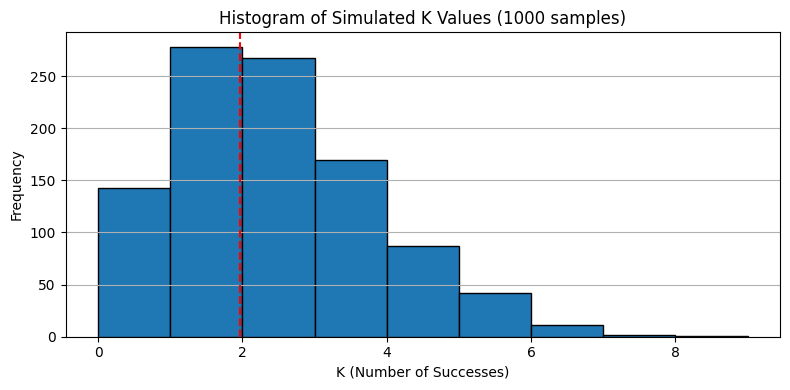

 K Val  Freq
     0   143
     1   278
     2   267
     3   169
     4    87
     5    42
     6    11
     7     2
     8     1


In [26]:
# c

import pandas as pd

N = rng.poisson(lam=20, size=1000)
p = 0.1

K = rng.binomial(N, p)
k_count = pd.Series(K).value_counts().sort_index()
k_freq = k_count.reset_index()
k_freq.columns = ['K Val', "Freq"]

print(np.mean(K))

plt.figure(figsize=(8, 4))

plt.hist(K, bins=range(min(K), max(K)+2), edgecolor='black')
plt.axvline(np.mean(K), color='red', linestyle='--')
plt.title("Histogram of Simulated K Values (1000 samples)")
plt.xlabel("K (Number of Successes)")
plt.ylabel("Frequency")
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

print(k_freq.to_string(index=False))

**Summary (1c):** The simulated histogram matches the Poisson(2) PMF very closely. The simulated mean is approximately 2 and the variance is also approximately 2 (since Poisson distributions have equal mean and variance). This confirms the theoretical result that $K \sim \text{Poisson}(\lambda p) = \text{Poisson}(2)$.

## 2. Tulips

You are working with a tulip farmer to improve the color of a new variety of blue tulip.
After many measurements, in which you've summarized the color of each tulip flower by a single wavelength,
you've determined that
- color values range from about 450-500nm (possibly with occasional tulips outside this range)
- the average tulip color is fairly blue: about 475nm
- the standard deviation of color across flowers from a single plant tends to be around 5nm
- however, some tulip plants produce more variable colors than others: most plants have standard deviations below 10nm,
  but some (roughly 10%) have larger standard deviations.

**(a)** Develop a model for $C$, the color value (measured as wavelengths, in nm) of a randomly chosen tulip in the field,
using at least two different distributions, formulated as in the last question.
Make sure all parameters are specified, and explain your choice of distributions.

- My model has 2 different components and assumes flower color is Normally distributed.

- With 90% probability, a tulip comes from a "normal" plant $\rightarrow$ low variability group.  

- With 10% probability, a tulip comes from a "variable" plant $\rightarrow$ high variability group.  

  Both groups are centered around 475 nm.

- **Normal group (low variation):**  
$C_1 \sim \mathcal{N}(\text{mean}=475,\ \text{sd}=5,\ n=100)$

- **Variable group (high variation):**  
$C_2 \sim \mathcal{N}(\text{mean}=475,\ \text{sd}=12,\ n=100)$

- **One-line mixture form:**  
$$
C \sim 0.9 \cdot \mathcal{N}(475, 5^2) + 0.1 \cdot \mathcal{N}(475, 12^2)
$$

**(b)** Simulate 100 tulip colors, and verify that the resulting values agree with the verbal description above.
You do not have to explicitly simulate the separate plants (i.e., you may assume that each flower comes from a separate plant).

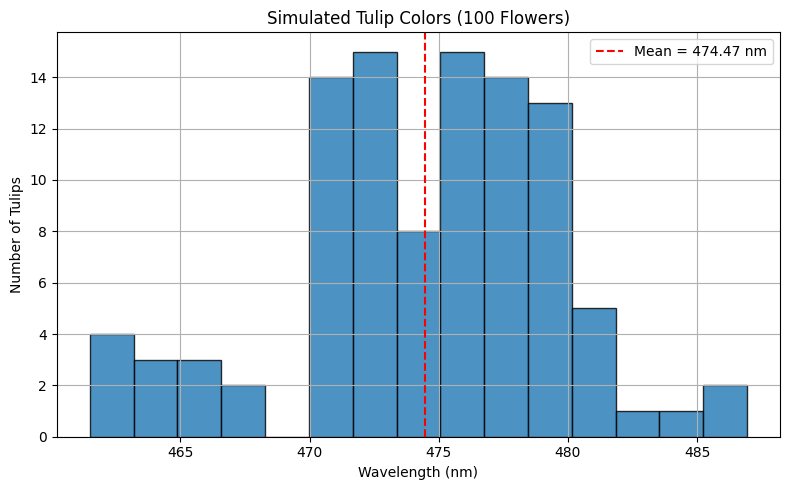

In [27]:
# b
n = 100
p_variable = 0.1

# identify high-variance flowers (10%)
is_variable = rng.random(n) < p_variable

# simulate colors from mixture model
colors = np.where(
    is_variable,
    np.random.normal(475, 10, size=n),  # high variability plants
    np.random.normal(475, 5, size=n)    # normal plants
)


plt.figure(figsize=(8, 5))

plt.hist(colors, bins=15, edgecolor='black', alpha=0.8)

mean_color = np.mean(colors)
plt.axvline(mean_color, color='red', linestyle='--',
            label=f"Mean = {mean_color:.2f} nm")

plt.title("Simulated Tulip Colors (100 Flowers)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Number of Tulips")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

- Interpretation: The histogram shows that simulated tulip wavelengths are centered around approximately 475 nm, with most flowers tightly clustered near this value due to the low-variability group, while a smaller number of flowers are more spread out and create wider tails because of the high-variability group.

## 3. Your stochastic day

Give examples from your day of quantities that might be reasonably modeled as random draws from the following distributions:

**(a)** Binomial
- The number of lectures I attend where I arrive on time in a week. Suppose I have 10 classes per week, and I arrive on time with probability p = 0.8 for each class.  

- X ~ Binomial(n = 10, p = 0.8)

- Each class is a trial (on time / late), and the total number of on-time arrivals varies from week to week.

**(b)** Normal
- The amount of sleep I get on weeknights. On average, I sleep about 7.5 hours, but it varies slightly due to homework, studying, and social plans.

- X ~ Normal(μ = 7.5, σ = 1.0)

- Most nights are close to 7.5 hours, with occasional shorter or longer nights.

**(c)** Poisson
- The number of emails or Canvas notifications I receive per day. On average, I get about 4 per day, but the exact number changes randomly.

- X ~ Poisson(λ = 4)

- These notifications arrive independently throughout the day.

**(d)** Exponential 
- The time between checking my phone while studying. Sometimes I check it quickly, other times I go longer without checking.

- T ~ Exponential(λ = 0.2)

- This corresponds to an average waiting time of 5 minutes between phone checks.

-------------------------------------------------------------------------------------------------------

In each case, give example parameter values (i.e., for (a), say what $n$ and $p$ are in your example).

*Example:* Every day I tie my shoes twice. Each time, there is a probability of about 5% that I'll need to untie them to adjust.
The number of times I don't tie a shoe correctly on the first time in a day is Binomial($n=4$, $p=0.05$). (It is $n=4$ for two shoes, two times.)

*Example:* My eight-year-old-kid sometimes takes a loooong time to put on *her* shoes (indeed, seemingly unboundedly long), but is more often quick.
The time she takes to put on her shoes in the morning is perhaps Exponential with a mean of 2 minutes.

## 4. Integrals

Suppose that the amount of time it takes me to write a page of text is $R$ minutes,
and I will make $X$ errors during that time.
Suppose that $R$ is [Gamma distributed](https://en.wikipedia.org/wiki/Gamma_distribution) with shape $\alpha=5$ and scale $\theta=4$.
Also, I make more errors the longer I type: the number of errors is Poisson, with mean $R/5$.
In symbols:
$$\begin{aligned}
\text{total time: } R &\sim \text{Gamma}(\text{scale}=4, \text{shape}=5) \\
\text{number of errors: } X &\sim \text{Poisson}(\text{mean}=R/5) .
\end{aligned}$$

**(a)** Suppose that for a given page I took $r$ minutes (i.e., I had $R=r$).
What is the probability that I made no errors? Write down the expression, and evaluate it for $r=20$.

- Given that $R = r$, the number of errors is $X \sim \text{Poisson}(r/5)$.
The probability of zero errors from a Poisson$(\mu)$ distribution is $e^{-\mu}$, so:
$$P(X = 0 \mid R = r) = e^{-r/5}$$

- Evaluated at $r = 20$:
$$P(X = 0 \mid R = 20) = e^{-20/5} = e^{-4} \approx 0.01832$$

**(b)** Now, what is the probability I made no errors on a randomly chosen page?
To do this, write down the integral which averages your expression for (a) over possible values of $R$.

- To get the unconditional probability of no errors, we average over all possible values of $R$ using the law of total probability:

$$P(X = 0) = \int_0^\infty P(X=0 \mid R=r) \cdot f_R(r)\, dr = \int_0^\infty e^{-r/5} \cdot f_R(r)\, dr$$

where $f_R(r)$ is the PDF of $\text{Gamma}(\text{shape}=5, \text{scale}=4)$:

$$f_R(r) = \frac{r^{\alpha-1} e^{-r/\theta}}{\theta^\alpha \,\Gamma(\alpha)} = \frac{r^{4} e^{-r/4}}{4^5 \cdot 24}, \quad r > 0$$

So the full integral is:

$$P(X=0) = \int_0^\infty e^{-r/5} \cdot \frac{r^{4} e^{-r/4}}{4^5 \cdot 24}\, dr = \int_0^\infty \frac{r^4 \, e^{-r(1/5 + 1/4)}}{4^5 \cdot 24}\, dr$$

**(c)** Now use software (for instance, [`np.trapezoid()`](https://numpy.org/devdocs/reference/generated/numpy.trapezoid.html), or some symbolic algebra software that can "do" integrals) to find a value for the integral. *Note: you could use [`scipy.stats.gamma.pdf`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gamma.html) for the probability density function of the Gamma distribution.*

**(d)** Check your answer to (b) by simulating at least 10000 draws from the distribution.

Estimated probability of making no errors: 0.0529
Numerical integration error estimate: 3.79e-11


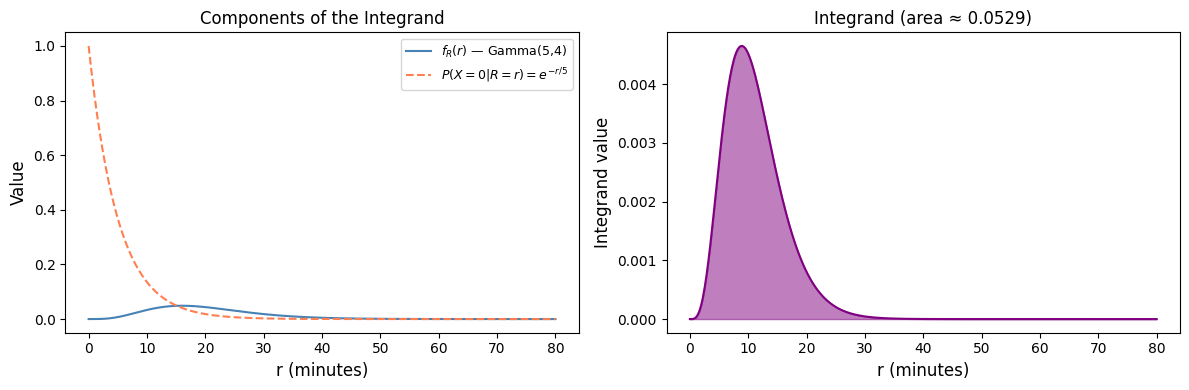

Numerical result: 0.052922
Analytic (5/9)^5: 0.052922
Both agree — the integration range and grid are sufficient.


In [28]:
# c
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma
from scipy.integrate import quad

alpha = 5
theta = 4

def integrand_func(r):
    return np.exp(-r / 5) * gamma.pdf(r, a=alpha, scale=theta)
prob_no_errors, error_estimate = quad(integrand_func, 0, np.inf)

print(f"Estimated probability of making no errors: {prob_no_errors:.4f}")
print(f"Numerical integration error estimate: {error_estimate:.2e}")

r_vals = np.linspace(0, 80, 500)

gamma_vals = gamma.pdf(r_vals, a=alpha, scale=theta)
exp_vals = np.exp(-r_vals / 5)
integrand_vals = exp_vals * gamma_vals


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(r_vals, gamma_vals,
         label=r'$f_R(r)$ — Gamma(5,4)', color='steelblue')
plt.plot(r_vals, exp_vals,
         label=r'$P(X=0|R=r) = e^{-r/5}$', color='coral', linestyle='--')
plt.xlabel('r (minutes)', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title('Components of the Integrand', fontsize=12)
plt.legend(fontsize=9)


plt.subplot(1, 2, 2)
plt.fill_between(r_vals, integrand_vals, alpha=0.5, color='purple')
plt.plot(r_vals, integrand_vals, color='purple')
plt.xlabel('r (minutes)', fontsize=12)
plt.ylabel('Integrand value', fontsize=12)
plt.title(f'Integrand (area ≈ {prob_no_errors:.4f})', fontsize=12)
plt.tight_layout()
plt.savefig('q4_integral.png', dpi=120, bbox_inches='tight')
plt.show()

# analytic comparison
analytic = (5/9)**5

print(f"Numerical result: {prob_no_errors:.6f}")
print(f"Analytic (5/9)^5: {analytic:.6f}")
print("Both agree — the integration range and grid are sufficient.")

- Interpretation: The product of the Gamma distribution and the zero-error probability gives the integrand. The area under this curve (~0.053) represents the probability of making no errors, and it matches the analytic result, confirming the model is correct.

Est P(X = 0) from sim: 0.0523


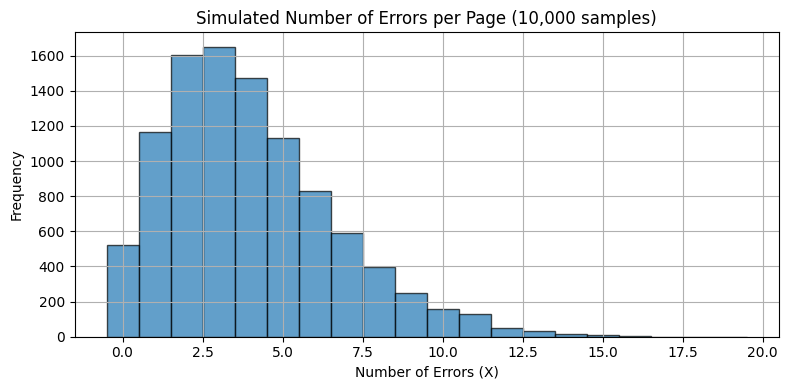

In [29]:
import numpy as np
import matplotlib.pyplot as plt

n = 10_000

r_samp = rng.gamma(shape=5, scale=4, size=n)
x_samp = rng.poisson(lam=r_samp / 5)
prob_no_errors = np.mean(x_samp == 0)

print(f"Est P(X = 0) from sim: {prob_no_errors:.4f}")


plt.figure(figsize=(8, 4))
plt.hist(x_samp, bins=np.arange(-0.5, 20.5, 1), edgecolor='black', alpha=0.7)
plt.title("Simulated Number of Errors per Page (10,000 samples)")
plt.xlabel("Number of Errors (X)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

- Interpretattion: Most pages have a small number of errors (around 2–5), with few pages having none and a small number having many errors.
